# Frage 1:

(10000, 3)
Zeitschritt dt = 0.001000 s
Abtastrate fs = 1000 Hz


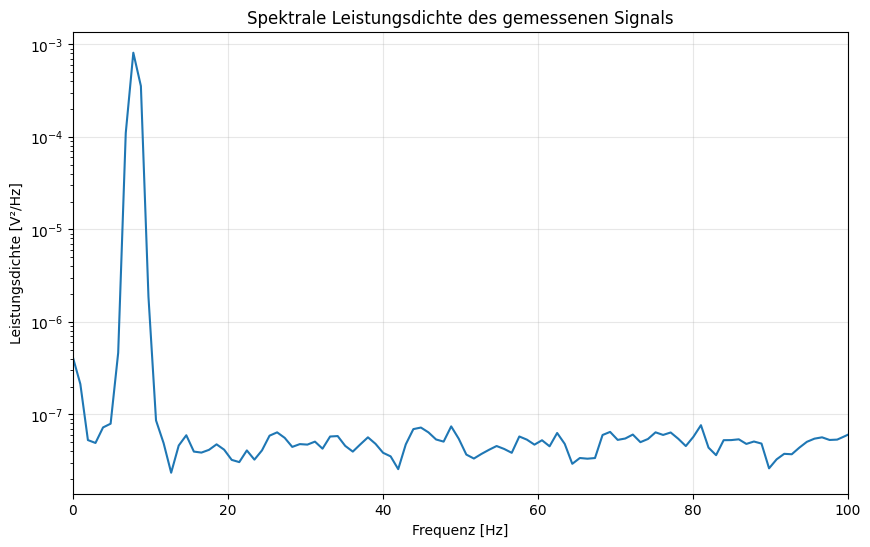

Dominante Frequenz: 7.81 Hz


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

data = np.loadtxt('seismic_test_dataset7.txt', skiprows=1, delimiter=',')
print(data.shape)

t = data[:,0] # time in seconds
V_signal = data[:,1] # signal from seismometer
V_noise = data[:,2] # noise from seismometer (should be zero, but is not due to imperfections in the seismometer)

dt = t[1] - t[0]
print(f"Zeitschritt dt = {dt:.6f} s")
print(f"Abtastrate fs = {1/dt:.0f} Hz")

f, Pxx = signal.welch(V_signal, fs=1/dt, nperseg=1024)

plt.figure(figsize=(10,6))
plt.semilogy(f, Pxx)
plt.xlabel('Frequenz [Hz]')
plt.ylabel('Leistungsdichte [V²/Hz]')
plt.title('Spektrale Leistungsdichte des gemessenen Signals')
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.show()

# Dominante Frequenz:
dominant_freq = f[np.argmax(Pxx)]
print(f"Dominante Frequenz: {dominant_freq:.2f} Hz")


# Frage 2:

In [2]:
var_signal = np.var(V_signal)
var_noise = np.var(V_noise)

var_seismic = var_signal - var_noise

print(f"Varianz des Signals: {var_signal:.6f} V^2")
print(f"Varianz des Rauschens: {var_noise:.6f} V^2")
print(f"Varianz des seismischen Signals: {var_seismic:.6f} V^2")

Varianz des Signals: 0.001272 V^2
Varianz des Rauschens: 0.000025 V^2
Varianz des seismischen Signals: 0.001247 V^2


# Frage 3:

In [3]:
cov_signal_noise = np.cov(V_signal, V_noise)[0, 1]

print(f"Kovarianz(Signal, Rauschen): {cov_signal_noise:.6f} V^2")
print(f"Varianz des Rauschens: {var_noise:.6f} V^2")
print(f"Differenz: {cov_signal_noise - var_noise:.10f} V^2")

Kovarianz(Signal, Rauschen): -0.000002 V^2
Varianz des Rauschens: 0.000025 V^2
Differenz: -0.0000275315 V^2


# Frage 4:

In [4]:
data = np.loadtxt('earthquake_waiting_times7.txt', skiprows=1)
print(data.shape)

print(f"\nAnzahl der Datenpunkte: {len(data)}")
print(f"Erste 5 Werte: {data[:5]} \n\n")

tau = np.mean(data)
print(f"Mittlere Wartezeit zwischen Erdbeben: {tau:.4f} Sekunden")

# Zeitintervall für bestimmung von Wahrscheinlichkeit
t = 30 # Sekunden

probability = 1 - np.exp(-t / tau)

probability_percent = probability * 100
print(f"\nWahrscheinlichkeit P(T ≤ 30 s) = {probability_percent:.4f}%")


(500,)

Anzahl der Datenpunkte: 500
Erste 5 Werte: [ 17.36291933 111.37449294  48.71959066  33.77887449   6.27612021] 


Mittlere Wartezeit zwischen Erdbeben: 37.1594 Sekunden

Wahrscheinlichkeit P(T ≤ 30 s) = 55.3953%
